In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
from scipy.io import mmread
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import os
import seaborn as sb
import scipy.stats as stats

In [2]:
adata=ad.read_h5ad("/nfs/team292/projects/PanTissue/data/temp/ATAC/processed/nonfetal_all/concatenated_processed.h5ad")


In [3]:
annot_outdir='/nfs/team292/projects/PanTissue/results/freeze/ATAC/annotations/'
markers_outdir='/nfs/team292/projects/PanTissue/results/freeze/ATAC/RNA_markers/'
rna_ref='/nfs/team292/projects/PanTissue/data/temp/GWASxRNA/RNA_references/nonfetal_all_downsampled.h5ad'

In [ ]:
plots_outdir="/nfs/team292/projects/PanTissue/data/temp/ATAC/processed/nonfetal_all/plots/"

In [5]:
adata.obs

,tissue,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,...,Cellranger_version,RNA_matched_sample_id,leiden,leiden_res5,leiden_res10,leiden_scanpy,leiden_scanpy_res5,leiden_scanpy_res10,coarse_predicted_annotation,final_tissue_annotation
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAAAGCGTAGCA-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,17.372,12835,12706,231,0.295530,1,0.738255,1287,...,NaN,NaN,7,8,60,8,2,24,Epi_FallopianSec_OVGP1lo,Epi_FallopianSec_OVGP1lo
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAACATCCCAAA-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,20.218,10680,9487,194,0.287276,1,0.537287,986,...,NaN,NaN,4,5,8,5,13,23,Mesen_FallopianFibs,Mesen_FallopianFibs
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAAGTAGGTCTT-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,17.111,10032,9278,160,0.247651,1,0.607897,1310,...,NaN,NaN,4,1,34,5,41,39,Mesen_FallopianFibs,Mesen_FallopianFibs
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAAGTTGAAGCG-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,20.462,8339,7224,130,0.301528,1,0.614420,1014,...,NaN,NaN,4,1,10,5,3,14,Mesen_FallopianFibs,Mesen_FallopianFibs
AB-ELHE-10x-scA-ATACFCA2509A#AAACTCGAGAATCAGT-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,18.274,9496,8733,176,0.312764,1,0.627156,1022,...,NaN,NaN,4,1,10,5,3,14,Mesen_FallopianFibs,Mesen_FallopianFibs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM5570640#TTTGGCCTCTAGTCGA-1,nonfetal_uterus,GSM5570640,6.447,2813,3421,103,0.162796,1,0.440302,329,...,NaN,NaN,13,28,33,13,62,134,Immune_DCs,Immune_DCs
GSM5570640#TTTGGTTCACTGAAGG-1,nonfetal_uterus,GSM5570640,6.065,1755,2326,72,0.112378,1,0.643742,989,...,NaN,NaN,3,13,36,3,27,6,Epi_EndoGlandFun_mlSec,Epi_EndoGlandFun_mlSec
GSM5570640#TTTGTGTCACAGGTAG-1,nonfetal_uterus,GSM5570640,11.772,6444,6269,149,0.189763,1,0.744613,1351,...,NaN,NaN,10,11,95,11,31,93,Immune_NK,Immune_NK
GSM5570640#TTTGTGTTCAGGGTTT-1,nonfetal_uterus,GSM5570640,8.764,4222,4621,106,0.146494,1,0.625309,1454,...,NaN,NaN,6,12,21,7,26,11,Mesen_EndoStromalFib_Sec,Mesen_EndoStromalFib_Sec


In [6]:
final_annot={'Immune_B': ['Immune_B_Memory', 'Immune_B_Naive'],
 'Immune_Plasma': ['Immune_Plasma_κ', 'Immune_Plasma_λ'],
 'Immune_DCs': ['Immune_cDC1',
  'Immune_cDC2',
  'Immune_cDC2_CD207',
  'Immune_mregDC',
  'Immune_pDC'],
 'Immune_Mono_Mac_EREG': ['Immune_MO_CD14hi_CD16lo',
  'Immune_MO_CD16hi_CD14lo',
  'Immune_Mac_EREG'],
 'Immune_Mac_LYVE1': ['Immune_Mac_LYVE1'],
 'Immune_Mac_TREM2': ['Immune_Mac_TREM2hi_IFNLR1hi',
  'Immune_Mac_TREM2hi',
  'Immune_Mac_TREM2hi_DHRS9'],
 'Immune_granulocytes': ['Immune_Mast',
  'Immune_Neutrophils',
  'Immune_Baso_Eosinophils'],
 'Immune_NK': ['Immune_NK_CD56hi_XCL1',
  'Immune_NK_CD56hi_CD160',
  'Immune_NK_CD56hi_B4GALNT1',
  'Immune_NK_CD16hi',
  'Immune_NK_CD56_16dim_SPTSSBhi',
  'Immune_NK_CD56hi_ISGs'],
 'Immune_NKT': ['Immune_NKT_gdT'],
 'Immune_ILC3': ['Immune_ILC3_PCDH9', 'Immune_ILC3'],
 'Immune_CD8_T': ['Immune_CD8_T_RM_GZMK',
  'Immune_CD8_T_EM',
  'Immune_CD8_T_RM',
  'Immune_CD8_T_N'],
 'Immune_CD4_T': ['Immune_CD4_Th17','Immune_CD4_Treg',
  'Immune_CD4_Th2-SCM',
  'Immune_CD4_T_Unpolarised',
  'Immune_CD4_T_N'],
 'Immune_MAIT': ['Immune_MAIT'],
 'Endo_cap_ven': ['Endo_cap',
  'Endo_cap_CA4',
  'Endo_cap_tip',
  'Endo_cap_APCDD1',
  'Endo_ven_hev',
  'Endo_ven_pcv',
  'Endo_ven_tpcv',
  'Endo_ven_apcv',
  'Endo_ven'],
 'Endo_artery': ['Endo_artery'],
 'Endo_lymph': ['Endo_lymp'],
 'Mesen_pericytes': ['Mesen_Pericyte_SMCsIntr', 'Mesen_Pericyte'],
 'Mesen_vSMCs_smallArt': ['Mesen_vSMCs_smallArt'],
 'Mesen_vSMCs_largeArt': ['Mesen_vSMCs_largeArt'],
 'Mesen_Pericyte_EndoSpiralArt': ['Mesen_Pericyte_EndoSpiralArt'],
 'Mesen_AdvFibsIntr': ['Mesen_AdvFibsIntr'],
 'Mesen_AdvFibs_PI16low': ['Mesen_AdvFibs_PI16low'],
 'Mesen_AdvFibs_PI16hi': ['Mesen_AdvFibs_PI16hi'],
 'Neural': ['Neural_schwann', 'Neural_schwann_myelinating'],
 'Epi_EndoGlandLum_Prof': ['Epi_EndoGlandLum_Prof'],
 'Epi_EndoGlandLum_Sec': ['Epi_EndoGlandLum_eSec', 'Epi_EndoGlandLum_mSec'],
 'Epi_EndoGlandFun_Prof': ['Epi_EndoGlandFun_Prof', 'Epi_EndoGlandFun_Menstr'],
 'Epi_EndoGlandFun_eSec': ['Epi_EndoGlandFun_eSec'],
 'Epi_EndoGlandFun_emSec': ['Epi_EndoGlandFun_emSec'],
 'Epi_EndoGlandFun_mlSec': ['Epi_EndoGlandFun_mSec', 'Epi_EndoGlandFun_lSec'],
 'Epi_EndoCil': ['Epi_EndoCil_eProf', 'Epi_EndoCil_Diff'],
 'Mesen_EndoStromalFib_Prolif': ['Mesen_EndoStromalFib_Prolif',
  'Mesen_EndoStromalFib_MenstrualEutopic'],
 'Mesen_EndoStromalFib_Sec': ['Mesen_EndoStromalFib_eSec',
  'Mesen_EndoStromalFib_mSec',
  'Mesen_EndoStromalFib_lSec'],
 'Mesen_Pericyte_EndoStromalFib_Transitioning': ['Mesen_Pericyte_EndoStromalLike',
  'Mesen_EndoStromalFib_PericyteLike'],
 'Meso_OSE': ['Meso_OSE'],
 'Mesen_OvarianFibs_Medulla': ['Mesen_OvarianFibs_Medulla',
  'Mesen_OvarianFibs_Medulla_SMCsLike'],
 'Mesen_OvarianFibs_Inncor': ['Mesen_OvarianFibs_Inncor'],
 'Mesen_OvarianFibs_Outcor': ['Mesen_OvarianFibs_Outcor'],
 'Mesen_OvarianFibs_Perifol': ['Mesen_OvarianFibs_Perifol'],
 'Mesen_ThecaInterna_Steroid': ['Mesen_ThecaInterna_Steroid'],
 'Mesen_ThecaInterna_Perifol': ['Mesen_ThecaInterna_Perifol'],
 'Mesen_ThecaExterna': ['Mesen_ThecaExterna'],
 'Granulosa_AMHpos': ['Granulosa_AMHpos_Antral',
  'Granulosa_AMHpos_Multilayered',
  'Granulosa_AMHpos_Cumulus',
  'Granulosa_AMHpos_Primary'],
 'Granulosa_sq': ['Granulosa_sq'],
 'Granulosa_sq_Transitioning': ['Granulosa_sq_Transitioning'],
 'Germcells': ['Germcell_PrimaryOocyte_PIWIL3', 'Germcell_PrimaryOocyte'],
 'Meso_Serosa': ['Meso_Serosa'],
 'Mesen_SMCs': ['Mesen_SMCs'],
 'Epi_FallopianSec_OVGP1hi': ['Epi_FallopianSec_OVGP1hi'],
 'Epi_FallopianSec_OVGP1lo': ['Epi_FallopianSec_OVGP1lo',
  'Epi_FallopianSec_OVGP1lo_inflammatory'],
 'Epi_FallopianCil': ['Epi_FallopianCil_Diff', 'Epi_FallopianCil_Early'],
 'Mesen_FallopianFibs': ['Mesen_FallopianFibs',
  'Mesen_UterotubalJunctionFibs']}
adata.obs["final_annotation"]=adata.obs["predicted_annotation_unconstrained"].map({value: category for category, values in final_annot.items() for value in values}).tolist()

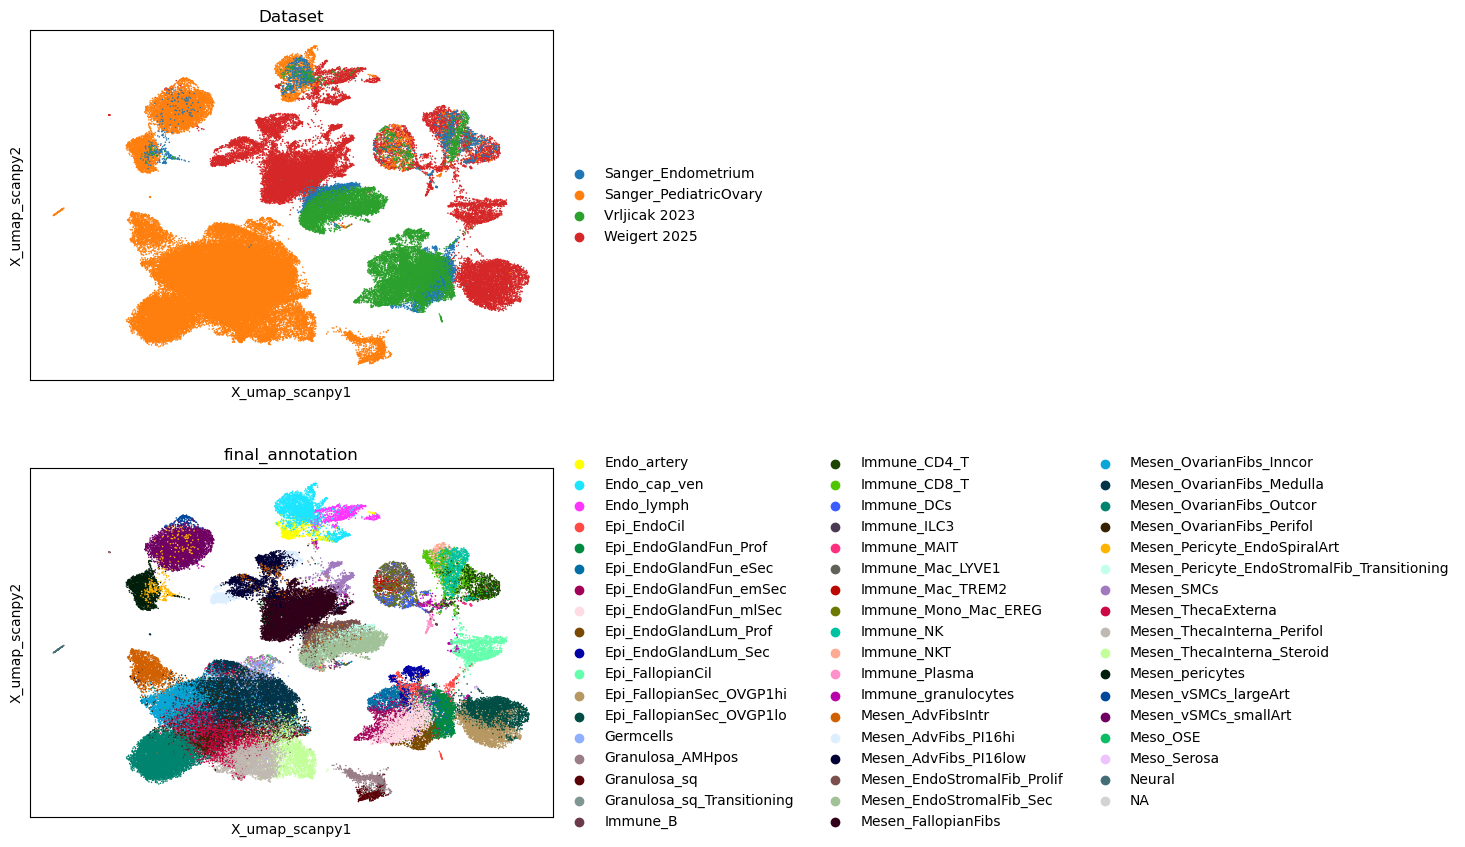

In [ ]:
sc.pl.embedding(adata,basis='X_umap_scanpy',color=['Dataset','final_annotation'],ncols=1,size=5)

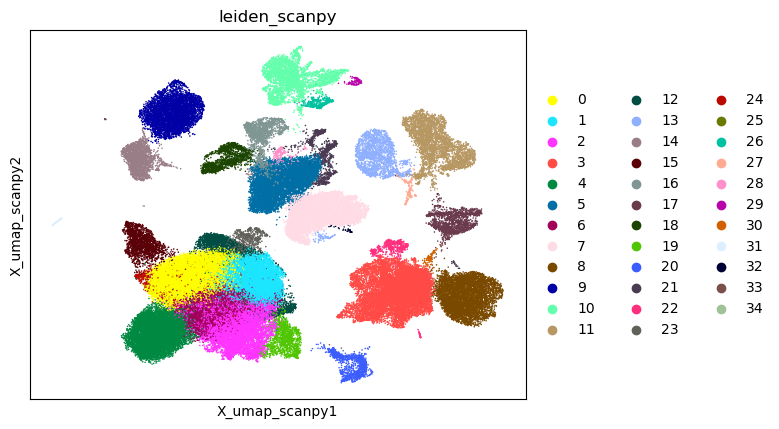

In [ ]:
sc.pl.embedding(adata,basis='X_umap_scanpy',color=['leiden_scanpy'],size=5)

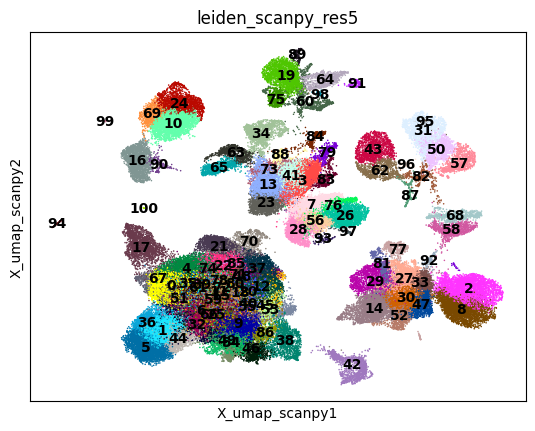

In [ ]:
sc.pl.embedding(adata,basis='X_umap_scanpy',color=['leiden_scanpy_res5'],ncols=1,size=5, legend_loc='on data')

In [7]:
remove_clusters=['99','100','93']
#also remove cells from cluster 79 that are not in Meso_Serosa or Mesen_SMCs since it's split in 2 and it doesn't make sense
adata.obs['final_annotation'] = adata.obs['final_annotation']#.cat.add_categories('lowQC')
adata.obs.final_annotation[adata.obs.leiden_scanpy_res5.isin(remove_clusters)]='lowQC'
adata.obs.final_annotation[(adata.obs.leiden_scanpy_res5=='79') & ~(adata.obs.final_annotation.isin(['Meso_Serosa','Mesen_SMCs']))]='lowQC'

/tmp/ipykernel_3519700/3340570487.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata.obs.final_annotation[adata.obs.leiden_scanpy_res5.isin(remove_clusters)]='lowQC'
/tmp/ipykernel_3519700/3340570487.py:4: SettingWithCopyWarning: 
A v

In [8]:
#cluster into lineages and remove cells in the wrong lineage clusters
adata.obs['lineage_parsed'] = adata.obs['final_annotation'].str.split('_').str[0] #get lineage from coarse annot
cluster_lineage_counts = (adata.obs.groupby(['leiden_scanpy_res5', 'lineage_parsed']).size().reset_index(name='count')) #get number of cells per lineage per cluster
dominant_lineage = (
    cluster_lineage_counts[cluster_lineage_counts['lineage_parsed'] != 'lowQC']
    .sort_values('count', ascending=False)
    .groupby('leiden_scanpy_res5')
    .first()
    .reset_index()[['leiden_scanpy_res5', 'lineage_parsed']]
    .rename(columns={'lineage_parsed': 'cluster_lineage'}))

if 'cluster_lineage' in adata.obs.columns:
	adata.obs=adata.obs.drop(columns=['cluster_lineage'])#drop any existing cluster_lineage column
adata.obs = adata.obs.merge(dominant_lineage, on='leiden_scanpy_res5', how='left')\
    .set_index(adata.obs.index) #add top lineage per cluster column

# flag wrong lineage
adata.obs['wrong_lineage'] = adata.obs['lineage_parsed'] != adata.obs['cluster_lineage']
#obs['wrong_lineage'] = adata.obs['wrong_lineage'].reindex(obs.index).fillna(False)

/tmp/ipykernel_3519700/1046701482.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_lineage_counts = (adata.obs.groupby(['leiden_scanpy_res5', 'lineage_parsed']).size().reset_index(name='count')) #get number of cells per lineage per cluster
/tmp/ipykernel_3519700/1046701482.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('leiden_scanpy_res5')


In [9]:
adata.obs.final_annotation[adata.obs['wrong_lineage']]='lowQC'
adata.obs.loc[adata.obs.predicted_annotation_unconstrained.isin(['Meso_Serosa','Meso_OSE']), 'final_annotation'] = \
    adata.obs.loc[adata.obs.predicted_annotation_unconstrained.isin(['Meso_Serosa','Meso_OSE']), 'predicted_annotation_unconstrained'].astype(str)

/tmp/ipykernel_3519700/2020957537.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata.obs.final_annotation[adata.obs['wrong_lineage']]='lowQC'
/tmp/ipykernel_3519700/2020957537.py:1: SettingWithCopyWarning: 
A value is trying to be set

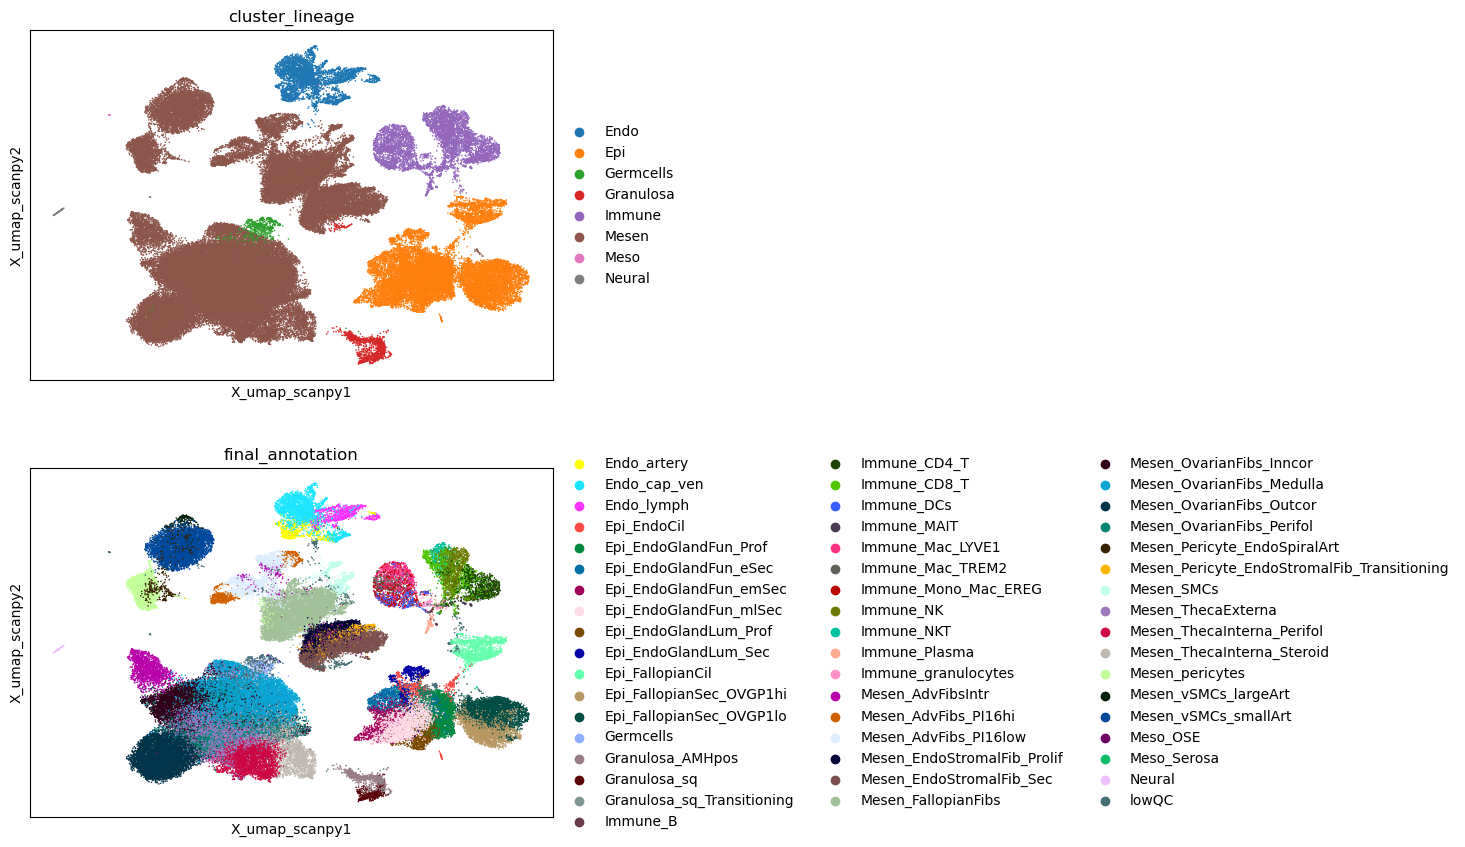

In [26]:
sc.pl.embedding(adata,basis='X_umap_scanpy',color=['cluster_lineage','final_annotation'],ncols=1,size=5)

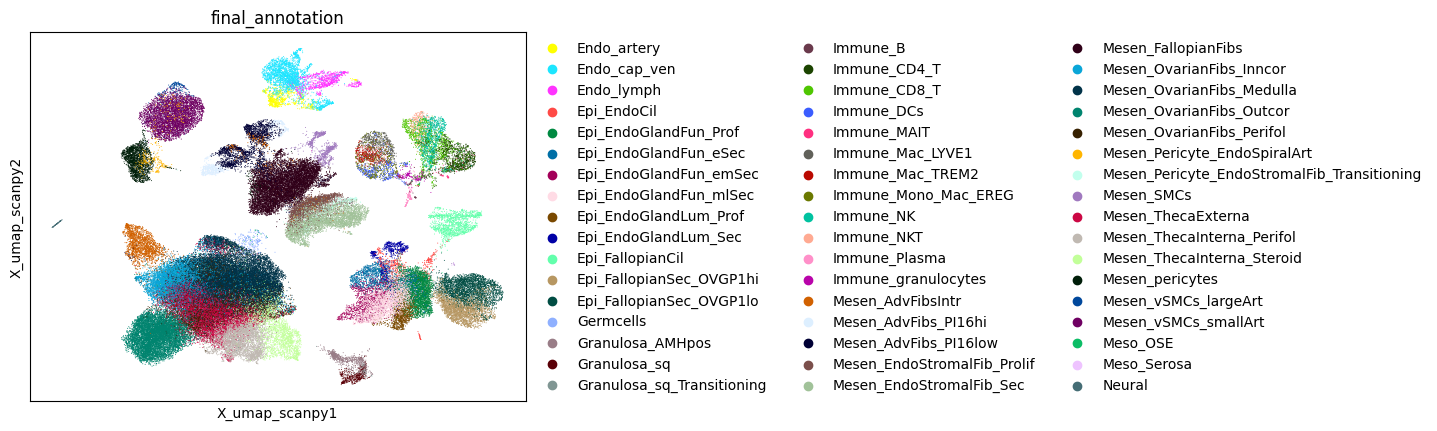

In [203]:
sc.pl.embedding(adata[~(adata.obs.final_annotation=='lowQC')],basis='X_umap_scanpy',color=['final_annotation'],ncols=1,size=2)

In [11]:
adata.obs

,tissue,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,ReadsInBlacklist,PromoterRatio,PassQC,NucleosomeRatio,nMultiFrags,...,leiden_res10,leiden_scanpy,leiden_scanpy_res5,leiden_scanpy_res10,coarse_predicted_annotation,final_tissue_annotation,final_annotation,lineage_parsed,cluster_lineage,wrong_lineage
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAAAGCGTAGCA-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,17.372,12835,12706,231,0.295530,1,0.738255,1287,...,60,8,2,24,Epi_FallopianSec_OVGP1lo,Epi_FallopianSec_OVGP1lo,Epi_FallopianSec_OVGP1lo,Epi,Epi,False
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAACATCCCAAA-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,20.218,10680,9487,194,0.287276,1,0.537287,986,...,8,5,13,23,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen,Mesen,False
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAAGTAGGTCTT-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,17.111,10032,9278,160,0.247651,1,0.607897,1310,...,34,5,41,39,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen,Mesen,False
AB-ELHE-10x-scA-ATACFCA2509A#AAACGAAGTTGAAGCG-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,20.462,8339,7224,130,0.301528,1,0.614420,1014,...,10,5,3,14,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen,Mesen,False
AB-ELHE-10x-scA-ATACFCA2509A#AAACTCGAGAATCAGT-1,nonfetal_fallopiantube,AB-ELHE-10x-scA-ATACFCA2509A,18.274,9496,8733,176,0.312764,1,0.627156,1022,...,10,5,3,14,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen_FallopianFibs,Mesen,Mesen,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM5570640#TTTGGCCTCTAGTCGA-1,nonfetal_uterus,GSM5570640,6.447,2813,3421,103,0.162796,1,0.440302,329,...,33,13,62,134,Immune_DCs,Immune_DCs,Immune_DCs,Immune,Immune,False
GSM5570640#TTTGGTTCACTGAAGG-1,nonfetal_uterus,GSM5570640,6.065,1755,2326,72,0.112378,1,0.643742,989,...,36,3,27,6,Epi_EndoGlandFun_mlSec,Epi_EndoGlandFun_mlSec,Epi_EndoGlandFun_mlSec,Epi,Epi,False
GSM5570640#TTTGTGTCACAGGTAG-1,nonfetal_uterus,GSM5570640,11.772,6444,6269,149,0.189763,1,0.744613,1351,...,95,11,31,93,Immune_NK,Immune_NK,Immune_NK,Immune,Immune,False
GSM5570640#TTTGTGTTCAGGGTTT-1,nonfetal_uterus,GSM5570640,8.764,4222,4621,106,0.146494,1,0.625309,1454,...,21,7,26,11,Mesen_EndoStromalFib_Sec,Mesen_EndoStromalFib_Sec,Mesen_EndoStromalFib_Sec,Mesen,Mesen,False


In [12]:
obs=adata.obs
obs.to_csv(annot_outdir+'alltissues.csv')

In [13]:
adata=adata[~(adata.obs.final_annotation=='lowQC')]

In [14]:
with PdfPages(plots_outdir+'labeltransfer_umaps_scanpy_size5.pdf') as pdf:
    sc.set_figure_params(dpi=300, frameon=False, figsize=(5, 5))
    for var in ['Sample','TSSEnrichment','nFrags','DoubletScore','is_doublet','doublet_score','doublet_probability',
                'Organ','Dataset','Sample_id','Donor_id','Stage','Menstrual_stage', 'final_annotation']:
        fig = sc.pl.embedding(adata, basis="X_umap_scanpy",color=var, return_fig=True, show=False,size=5)
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.close(fig)

with PdfPages(plots_outdir+'labeltransfer_umaps_scanpy.pdf') as pdf:
    sc.set_figure_params(dpi=300, frameon=False, figsize=(5, 5))
    for var in ['Sample','TSSEnrichment','nFrags','DoubletScore','is_doublet','doublet_score','doublet_probability',
                'Organ','Dataset','Sample_id','Donor_id','Stage','Menstrual_stage', 'final_annotation']:
        fig = sc.pl.embedding(adata, basis="X_umap_scanpy",color=var, return_fig=True, show=False)
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
        plt.close(fig)

/software/cellgen/team292/cc53/my-conda-envs/singlecellatlas_large-cc53/lib/python3.12/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team292/cc53/my-conda-envs/singlecellatlas_large-cc53/lib/python3.12/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team292/cc53/my-conda-envs/singlecellatlas_large-cc53/lib/python3.12/site-packages/anndata/_core/anndata.py:1180: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats
from scipy.sparse import issparse, csr_matrix


def get_mean_expression(adata, genes, groupby='celltype'):
    genes_present = [g for g in genes if g in adata.var_names]
    gene_idx = adata.var_names.isin(genes_present)
    X = adata.X[:, gene_idx]
    if not issparse(X):
        X = csr_matrix(X)
    groups = pd.Categorical(adata.obs[groupby])
    mean_expr = pd.DataFrame(
        np.vstack([np.asarray(X[groups == g].mean(axis=0)).flatten()
                   for g in groups.categories]),
        index=groups.categories,
        columns=adata.var_names[gene_idx],
    )
    return mean_expr


def markers_heatmap(
    adata,
    groupby,
    marker_genes,
    celltype_order=None,
    marker_order=None,
    width=12,
    height=8,
    show_gene_labels=False,
    show_category_labels=False,
    vertical=False,
    fontsize=8,
    save=None,
):
    """
    Parameters
    ----------
    adata                 AnnData object
    groupby               obs column for cell type grouping
    marker_genes          dict of {category: [gene, ...]}
    celltype_order        optional list to reorder cell type columns/rows
    marker_order          optional list to reorder marker categories (and their genes)
    width, height         figure dimensions in inches
    show_gene_labels      show individual gene names on the gene axis
    show_category_labels  show marker category names over/beside the colour bar
    vertical              cell types on x-axis, genes on y-axis;
                          colour bar on left, gene names on right
    fontsize              font size applied uniformly to all text elements
    save                  path to save figure (e.g. 'heatmap.pdf', 'heatmap.png')
    """
    # Reorder marker categories if requested
    if marker_order is not None:
        marker_genes = {k: marker_genes[k] for k in marker_order if k in marker_genes}

    all_markers = [g for genes in marker_genes.values() for g in genes]

    group_sizes = adata.obs[groupby].value_counts()
    valid_groups = group_sizes[group_sizes >= 10].index
    adata = adata[adata.obs[groupby].isin(valid_groups)].copy()
    adata.obs[groupby] = adata.obs[groupby].cat.remove_unused_categories()

    mean_expr = get_mean_expression(adata, all_markers, groupby=groupby)

    z_scores = pd.DataFrame(
        stats.zscore(mean_expr.values, axis=0, nan_policy='omit'),
        index=mean_expr.index,
        columns=mean_expr.columns,
    ).T.fillna(0)

    ordered_genes, ordered_celltypes = [], []
    for celltype, genes in marker_genes.items():
        for gene in genes:
            if gene in z_scores.index:
                ordered_genes.append(gene)
                ordered_celltypes.append(celltype)

    z_ordered = z_scores.loc[ordered_genes].copy()
    z_ordered.index = [
        f"{g}__{ct}" for g, ct in zip(ordered_genes, ordered_celltypes)
    ]

    if celltype_order is not None:
        celltype_order = [c for c in celltype_order if c in z_ordered.columns]
        z_ordered = z_ordered[celltype_order]

    unique_celltypes = list(marker_genes.keys())
    n = len(unique_celltypes)
    if n <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))[:n]
    elif n <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, 20))[:n]
    else:
        colors = np.vstack([
            plt.cm.tab20(np.linspace(0, 1, 20)),
            plt.cm.tab20b(np.linspace(0, 1, 20)),
        ])[:n]
    celltype_colors = dict(zip(unique_celltypes, colors))

    n_genes = len(ordered_genes)

    boundaries = []
    prev_ct = ordered_celltypes[0]
    start = 0
    for i, ct in enumerate(ordered_celltypes):
        if ct != prev_ct:
            boundaries.append((prev_ct, start, i))
            start = i
            prev_ct = ct
    boundaries.append((prev_ct, start, n_genes))

    # ------------------------------------------------------------------
    # Horizontal layout
    # ------------------------------------------------------------------
    if not vertical:
        fig, (bar_ax, heat_ax) = plt.subplots(
            2, 1,
            figsize=(width, height),
            gridspec_kw={'height_ratios': [0.03, 1], 'hspace': 0.01},
            constrained_layout=True,
        )

        sb.heatmap(
            z_ordered.T.astype(float),
            cmap='viridis',
            cbar_kws={'label': 'Z-score', 'shrink': 0.5},
            linewidths=0,
            linecolor='none',
            annot=False,
            ax=heat_ax,
            vmin=-3.5, vmax=3.5,
            yticklabels=True,
            xticklabels=show_gene_labels,
        )
        heat_ax.set_xlabel('Gene' if show_gene_labels else '', fontsize=fontsize)
        heat_ax.set_ylabel('Cell type', fontsize=fontsize)
        heat_ax.tick_params(axis='both', labelsize=fontsize)
        heat_ax.grid(False)
        heat_ax.set_facecolor('none')

        if show_gene_labels:
            heat_ax.set_xticklabels(ordered_genes, rotation=90, fontsize=fontsize)

        cbar = heat_ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label('Z-score', fontsize=fontsize)

        fig.canvas.draw()
        for i, ct in enumerate(ordered_celltypes):
            bar_ax.axvspan(
                i / n_genes, (i + 1) / n_genes,
                facecolor=celltype_colors[ct], edgecolor='none',
            )
        bar_ax.set_xlim(0, 1)
        bar_ax.axis('off')

        if show_category_labels:
            for ct, s, e in boundaries:
                x = s / n_genes
                bar_ax.text(
                    x, 1.0, ct,
                    ha='left', va='bottom',
                    fontsize=fontsize,
                    rotation=45,
                    transform=bar_ax.transAxes,
                    clip_on=False,
                )

    # ------------------------------------------------------------------
    # Vertical layout
    # ------------------------------------------------------------------
    else:
        width_ratios = [0.03]
        if show_category_labels:
            width_ratios.append(0.06)
        width_ratios.append(1)

        fig, axes = plt.subplots(
            1, len(width_ratios),
            figsize=(width, height),
            gridspec_kw={'width_ratios': width_ratios, 'wspace': 0.01},
            constrained_layout=True,
        )
        axes = list(axes)
        bar_ax = axes[0]
        cat_ax = axes[1] if show_category_labels else None
        heat_ax = axes[-1]

        sb.heatmap(
            z_ordered.astype(float),
            cmap='viridis',
            cbar_kws={'label': 'Z-score', 'shrink': 0.5},
            linewidths=0,
            linecolor='none',
            annot=False,
            ax=heat_ax,
            vmin=-3.5, vmax=3.5,
            xticklabels=True,
            yticklabels=show_gene_labels,
        )
        heat_ax.set_xlabel('Cell type', fontsize=fontsize)
        heat_ax.set_ylabel('Gene' if show_gene_labels else '', fontsize=fontsize)
        heat_ax.tick_params(axis='both', labelsize=fontsize)
        heat_ax.xaxis.set_tick_params(rotation=45)
        heat_ax.grid(False)
        heat_ax.set_facecolor('none')

        if show_gene_labels:
            heat_ax.set_yticklabels(ordered_genes, rotation=0, fontsize=fontsize)

        cbar = heat_ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label('Z-score', fontsize=fontsize)

        fig.canvas.draw()
        for i, ct in enumerate(ordered_celltypes):
            bar_ax.axhspan(
                1 - (i + 1) / n_genes,
                1 - i / n_genes,
                facecolor=celltype_colors[ct], edgecolor='none',
            )
        bar_ax.set_ylim(0, 1)
        bar_ax.axis('off')

        if show_category_labels and cat_ax is not None:
            for ct, s, e in boundaries:
                y = 1 - s / n_genes
                cat_ax.text(
                    0.5, y, ct,
                    ha='center', va='top',
                    fontsize=fontsize,
                    rotation=90,
                    transform=cat_ax.transAxes,
                    clip_on=False,
                )
                cat_ax.axhspan(
                    1 - e / n_genes, 1 - s / n_genes,
                    facecolor=celltype_colors[ct], alpha=0.3, edgecolor='none',
                )
            cat_ax.set_ylim(0, 1)
            cat_ax.axis('off')

    if save is not None:
        fig.savefig(save, bbox_inches='tight')

    plt.close(fig)
    return fig




In [16]:
import sys
utils_path = '/nfs/team292/cc53/scripts/menstrual_fluid/scRNAseq_processing' 
sys.path.insert(0, utils_path)
import utils_noDEG as utils

#get markers from the RNA
rna=ad.read_h5ad(rna_ref)

In [17]:
rna.obs["final_ATAC_annotation"]=rna.obs["fine_celltype"].map({value: category for category, values in final_annot.items() for value in values}).tolist()

In [19]:
rna=rna[rna.obs.final_ATAC_annotation.isin(adata.obs.final_annotation)]

In [21]:
rna.obs.final_ATAC_annotation = rna.obs.final_ATAC_annotation.astype('category')
markers = utils.quick_markers(rna, cluster_key="final_ATAC_annotation", n_markers=20, r_output=True)

/software/cellgen/team292/cc53/my-conda-envs/singlecellatlas_large-cc53/lib/python3.12/site-packages/pandas/core/generic.py:6351: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self[name] = value
/nfs/team292/cc53/scripts/menstrual_fluid/scRNAseq_processing/utils_noDEG.py:268: RuntimeWarning: divide by zero encountered in divide
  idf = np.log(len(clusters) / n_tot)
/nfs/team292/cc53/scripts/menstrual_fluid/scRNAseq_processing/utils_noDEG.py:269: RuntimeWarning: invalid value encountered in multiply
  tf_idf = tf * idf


In [23]:
markers.to_csv(markers_outdir+'alltissues_fromRNA.csv')

In [ ]:
del rna
import gc
gc.collect()

In [25]:
marker_genes = markers.groupby('cluster')['gene'].apply(list).to_dict()

In [ ]:
hca_markers={
    'Endothelial':['PECAM1','VWF','CDH5','CLDN5','FLT1','PTPRB'],
	'Endo_artery':['GJA5','GJA4','SEMA3G'],
    'Endo_cap_ven':[],
    
	'Germcells':['DAZL','GDF9','ZP3','BMP15'],
    'Granulosa_AMHpos':['AMH'],
    'Granulosa_sq':['RDH10'], 
    #'Granulosa_sq_Transitioning':[],
    
	#'Immune':['PTPRC'],
	'Immune_Lymphoid':['PTPRC'],
    'Immune_Myeloid':['CD68'],

    'Mesenchymal':["PDGFRA", 'OGN','DCN', 'LUM'],    
    #'Mesen_OvarianFibs_AdvLike':[],
	#'Mesen_OvarianFibs_Inncor':[], 
	#'Mesen_OvarianFibs_Medulla':[],
    #'Mesen_OvarianFibs_Medulla_SMCsLike':[], 
	#'Mesen_OvarianFibs_Outcor':[],
	#'Mesen_OvarianFibs_Perifol':[], 
	
	'Mesen_Theca':['PTCH1','INSL3'],
	#'Mesen_ThecaExterna':[],
	#'Mesen_ThecaInterna_Perifol':[], 
	#'Mesen_ThecaInterna_Steroid':[],

	'Mesen_adventitial':['C7','DPT','C3'], 
	'Mesen_pericyte':['RGS5','KCNJ8','ABCC9'], 
	'Mesen_vSMCs':['ACTG2','MYH11','KCNMB1','DES','ATP1B1'], 
	'Meso_OSE':['UPK3B','LRRN4','LHX2'],
    'Neural':['S100B']
}

In [ ]:
final_annot={
 'Immune':['PTPRC'],
 'Immune_B': ['MS4A1','CD79A','PAX5','BANK1'],
 'Immune_Plasma': [],
 'Immune_DCs': ['FCER1A','CLEC10A','CD1C'],
 'Immune_Mono_Mac_EREG': [],
 'Immune_Mac_LYVE1': [],
 'Immune_Mac_TREM2': [],
 'Immune_granulocytes': [],
 'Immune_NK': ['CD56','GNLY','PRF1','KLRK1'],
 'Immune_NKT': [],
 'Immune_ILC3': [],
 'Immune_CD8_T': [],
 'Immune_CD4_T': [],
 'Immune_MAIT': [],

    'Endothelial':['PECAM1','VWF','CDH5','CLDN5','FLT1','PTPRB'],
 'Endo_cap_ven': [],
 'Endo_artery': ['GJA5','GJA4','SEMA3G'],
 'Endo_lymph': ['PROX1','LYVE1','CCL21'],

	'Mesenchymal':["PDGFRA", 'OGN','DCN', 'LUM'],
    'Mesen_Pericytes':['MYH11','RGS5','KCNJ8','ABCC9'],
 'Mesen_Pericyte_EndoSpiralArt': ['SLC38A11','STC2','FLT1','HOPX'],
 	'Mesen_vSMCs':['RERGL','MYH11'], 
 'Mesen_vSMCs_smallArt': ['NRGN','NET1'],
 'Mesen_vSMCs_largeArt': ['FOXC1','MT1M'],
 'Mesen_SMCs': ['ACTG2','MYH11','KCNMB1','DES','ATP1B1'],
	'Mesen_adventitial':['C7','DPT','C3'], 
 'Mesen_AdvFibsIntr': ['ACSM3','C7'],
 'Mesen_AdvFibs_PI16low': ['PI16','CD34','DPP4','SFRP2','C3','IL33','MFAP5','KCNB2','SCARA5','SLPI '],
 'Mesen_AdvFibs_PI16hi': ['C3','ABCA10','C7'],

'Mesen_EndoStromalFib_Prolif': ['MMP11','CRABP2','ECM1', 'KLK1'],
 'Mesen_EndoStromalFib_Sec': ['CFD','DKK1','IL15'],
 'Mesen_Pericyte_EndoStromalFib_Transitioning': ['MMP11','ANO4','RORB','DIO2'],
 'Mesen_OvarianFibs_Medulla': ['IGF2','ACTG2'],
 'Mesen_OvarianFibs_Inncor': ['PROK1'],
 'Mesen_OvarianFibs_Outcor': ['TSPAN8','TMEM100'],
 'Mesen_OvarianFibs_Perifol': ['PTCH1','LAMB1'],
	'Mesen_Theca':['PTCH1','INSL3'],
 'Mesen_ThecaInterna_Steroid': ['ANPEP','CYP17A1','GSTA1','LHCGR'],
 'Mesen_ThecaInterna_Perifol': ['ANPEP','CYP17A1','PIEZO2','THBD'],
 'Mesen_ThecaExterna': ['ACTG2'],
  'Mesen_FallopianFibs': ['HOXA7','GATA2'],

 'Neural': ['S100B'],

    'Epithelial':['EPCAM','PAX8'],
 'Epi_EndoGlandLum':['SULT1E1','CLDN22','LGR5'],
 'Epi_EndoGlandLum_Prof': ['MMP7','WNT7A'],
 'Epi_EndoGlandLum_Sec': ['LEFTY1','GPX3','IL6'],
 'Epi_EndoGlandFun_Prof': ['IHH', 'TRH','MMP7','SOX9'],
 #'Epi_EndoGlandFun_eSec': [],
 'Epi_EndoGlandFun_emSec': ['SPP1','S100P','SCGB2A2','DPP4'],
 'Epi_EndoGlandFun_lSec': ['PAEP'],
 'Epi_FallopianSec_OVGP1hi': ['OVGP1','LGR5','MKI67'],
 'Epi_FallopianSec_OVGP1lo': ['LYPD1','GPX3'],

 'Epi_EndoCil': ['FOXJ1','PIFO','CCNO'],
 'Epi_FallopianCil': ['WT1','PIFO','FOXJ1'],

 'Granulosa_AMHpos': ['AMH'],
 'Granulosa_sq': ['RDH10'],
 #'Granulosa_sq_Transitioning': [],
 'Germcells': ['DAZL','GDF9','ZP3','BMP15'],
 #'Meso_Serosa': [],
 
 	'Mesothelial':['UPK3B'],
 'Meso_OSE': ['LRRN4','LHX2'],}
adata.obs["final_annotation"]=adata.obs["predicted_annotation_unconstrained"].map({value: category for category, values in final_annot.items() for value in values}).tolist()

In [26]:
markers_heatmap(adata,groupby='final_annotation',marker_genes=marker_genes,height=3,width=12)

IndexError: list index out of range

In [ ]:
adata.var_names

Index(['chr1:0-500', 'chr1:500-1000', 'chr1:1000-1500', 'chr1:1500-2000',
       'chr1:2000-2500', 'chr1:2500-3000', 'chr1:3000-3500', 'chr1:3500-4000',
       'chr1:4000-4500', 'chr1:4500-5000',
       ...
       'chrX:156036000-156036500', 'chrX:156036500-156037000',
       'chrX:156037000-156037500', 'chrX:156037500-156038000',
       'chrX:156038000-156038500', 'chrX:156038500-156039000',
       'chrX:156039000-156039500', 'chrX:156039500-156040000',
       'chrX:156040000-156040500', 'chrX:156040500-156040895'],
      dtype='object', length=6062095)